Data loaded: 349x1905, 144 HS bands, 1 LiDAR bands, 15 classes.

Parameters:
dataset: Houston
flag_test: train
gpu_id: 0
seed: 42
batch_size: 64
grad_accum_steps: 2
test_freq: 20
patches: 14
epochs: 1000
learning_rate: 0.0003
weight_decay: 1e-05
window_size: 7
focal_alpha: 0.25
focal_gamma: 2.5
dropout_rate: 0.05
T_0: 50
T_mult: 2

=================================== Training ===================================
Epoch: 001 train_OA: 49.86
Epoch: 001 test_OA: 41.69, test_AA: 38.72, test_Kappa: 0.3723
*** Best model saved! OA: 41.69% at epoch 1 ***
Epoch: 021 train_OA: 99.08
Epoch: 021 test_OA: 89.12, test_AA: 90.04, test_Kappa: 0.8819
*** Best model saved! OA: 89.12% at epoch 21 ***
Epoch: 041 train_OA: 99.89
Epoch: 041 test_OA: 89.33, test_AA: 90.02, test_Kappa: 0.8842
*** Best model saved! OA: 89.33% at epoch 41 ***
Epoch: 061 train_OA: 99.08
Epoch: 061 test_OA: 86.91, test_AA: 88.10, test_Kappa: 0.8579
Epoch: 081 train_OA: 99.26
Epoch: 081 test_OA: 86.76, test_AA: 88.61, test_Kappa: 0

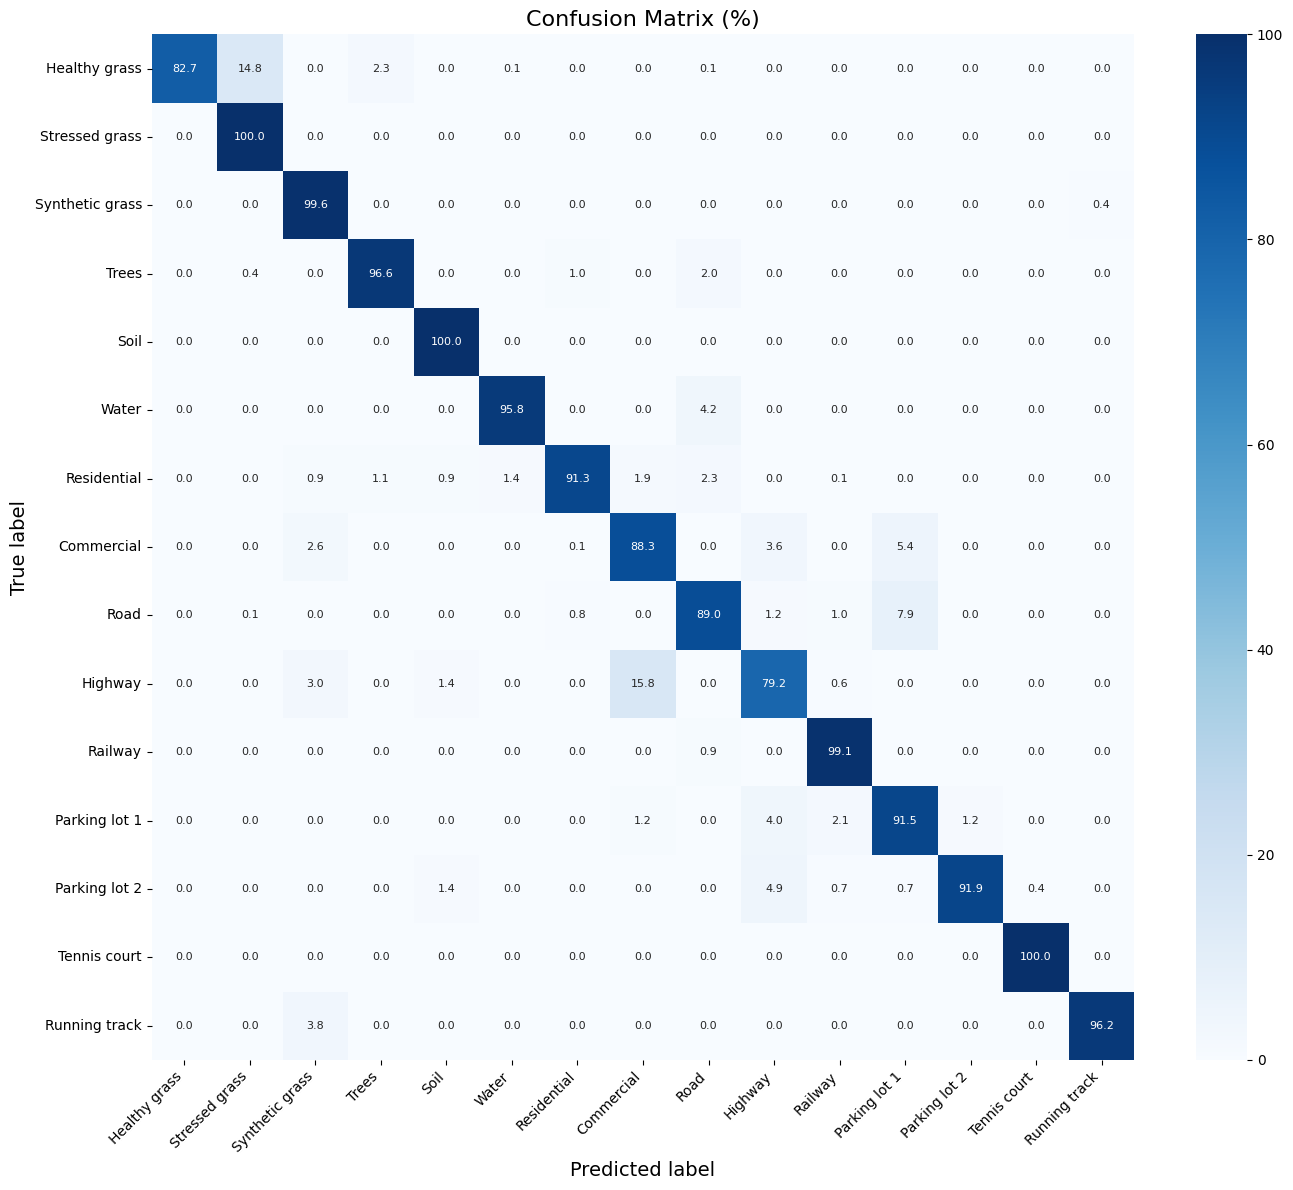

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
import torch.utils.data as Data
import torch.backends.cudnn as cudnn
from scipy.io import loadmat
from sklearn.metrics import confusion_matrix
import numpy as np
import time
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torchvision import transforms
from matplotlib.colors import ListedColormap ### MODIFIED ###: Import ListedColormap

# Suppress warnings
warnings.filterwarnings("ignore")

# --- Custom Focal Loss Implementation ---
class FocalLoss(nn.Module):
    """
    Focal Loss for classification tasks.
    It down-weights easy examples and focuses training on hard, misclassified examples.
    """
    def __init__(self, alpha=0.5, gamma=2.25, reduction='mean', ignore_index=-100):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ignore_index = ignore_index

    def forward(self, inputs, targets):
        if self.ignore_index != -100:
            valid_indices = (targets != self.ignore_index)
            inputs = inputs[valid_indices]
            targets = targets[valid_indices]
            if inputs.numel() == 0:
                return torch.tensor(0.0, device=inputs.device, requires_grad=True)
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss
        if self.reduction == 'mean':
            return F_loss.mean()
        elif self.reduction == 'sum':
            return F_loss.sum()
        else:
            return F_loss

# ===============================================================================
# STEP 1: SEPARABLE CONV TOKENIZER
# ===============================================================================
class SeparableConvTokenizer(nn.Module):
    """Separable Convolution-based Tokenizer for each modality"""
    def __init__(self, input_channels, output_dim, patch_size, dropout=0.0):
        super().__init__()
        nout = 16
        self.input_norm = nn.BatchNorm2d(input_channels)
        self.separable_conv = nn.Sequential(
            nn.Conv2d(input_channels, input_channels, kernel_size=3, padding=1, groups=input_channels),
            nn.BatchNorm2d(input_channels),
            nn.Conv2d(input_channels, nout, kernel_size=1),
            nn.BatchNorm2d(nout),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv2d(nout, nout, kernel_size=3, padding=1, groups=nout),
            nn.BatchNorm2d(nout),
            nn.Conv2d(nout, nout*2, kernel_size=1),
            nn.BatchNorm2d(nout*2),
            nn.Dropout(dropout),
            nn.GELU(),
            nn.Conv2d(nout*2, nout*2, kernel_size=3, padding=1, groups=nout*2),
            nn.BatchNorm2d(nout*2),
            nn.Conv2d(nout*2, nout*4, kernel_size=1),
            nn.BatchNorm2d(nout*4),
            nn.Dropout(dropout),
            nn.GELU(),
        )
        self.num_patches = patch_size * patch_size
        self.patch_embedding = nn.Linear(nout*4, output_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, output_dim) * 0.02)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.input_norm(x)
        x = self.separable_conv(x)
        x = rearrange(x, 'b c h w -> b (h w) c')
        x = self.patch_embedding(x)
        b, n, _ = x.shape
        if n <= self.pos_embedding.shape[1]:
            x += self.pos_embedding[:, :n]
        else:
            pos_emb = self.pos_embedding.repeat(1, (n // self.pos_embedding.shape[1]) + 1, 1)
            x += pos_emb[:, :n]
        x = self.dropout(x)
        return x

# ===============================================================================
# STEP 2: MODALITY-SPECIFIC TRANSFORMER BACKBONES (SWIN + BOTTLENECK BLOCKS)
# ===============================================================================
class WindowAttention(nn.Module):
    """Window-based Multi-Head Self Attention for Swin Transformer"""
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, qk_scale=None, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size - 1) * (2 * window_size - 1), num_heads))
        coords_h = torch.arange(self.window_size)
        coords_w = torch.arange(self.window_size)
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))
        coords_flatten = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:, :, 0] += self.window_size - 1
        relative_coords[:, :, 1] += self.window_size - 1
        relative_coords[:, :, 0] *= 2 * self.window_size - 1
        relative_position_index = relative_coords.sum(-1)
        self.register_buffer("relative_position_index", relative_position_index)
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        nn.init.trunc_normal_(self.relative_position_bias_table, std=.02)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))
        relative_position_bias = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size * self.window_size, self.window_size * self.window_size, -1)
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
        attn = attn + relative_position_bias.unsqueeze(0)
        attn = self.softmax(attn)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class BottleneckBlock(nn.Module):
    """Bottleneck Block for efficient feature processing"""
    def __init__(self, dim, reduction=4, dropout=0.05):
        super().__init__()
        reduced_dim = max(1, dim // reduction)
        self.bottleneck = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, reduced_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(reduced_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return x + self.bottleneck(x)

def window_partition(x, window_size):
    B, H, W, C = x.shape
    pad_l = pad_t = 0
    pad_r = (window_size - W % window_size) % window_size
    pad_b = (window_size - H % window_size) % window_size
    if pad_r > 0 or pad_b > 0:
        x = F.pad(x, (0, 0, pad_l, pad_r, pad_t, pad_b))
        _, H, W, _ = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W, original_H, original_W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    if H != original_H or W != original_W:
        x = x[:, :original_H, :original_W, :]
    return x

class SwinBottleneckBlock(nn.Module):
    """Swin Transformer Block with Bottleneck optimization"""
    def __init__(self, dim, input_resolution, num_heads, window_size=7, shift_size=0,
                 mlp_ratio=4., qkv_bias=True, qk_scale=None, drop=0., attn_drop=0.):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio
        if min(self.input_resolution) <= self.window_size:
            self.shift_size = 0
            self.window_size = min(self.input_resolution)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(
            dim, window_size=self.window_size, num_heads=num_heads,
            qkv_bias=qkv_bias, qk_scale=qk_scale, attn_drop=attn_drop, proj_drop=drop)
        self.bottleneck = BottleneckBlock(dim, reduction=max(1, int(mlp_ratio)), dropout=drop)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
        else:
            shifted_x = x
        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)
        attn_windows = self.attn(x_windows)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, shifted_x.shape[1], shifted_x.shape[2], H, W)
        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        else:
            x = shifted_x
        x = x.view(B, H * W, C)
        x = shortcut + x
        x = self.bottleneck(x)
        return x

class ModalitySpecificBackbone(nn.Module):
    """Modality-specific Transformer Backbone with Swin + Bottleneck Blocks"""
    def __init__(self, dim, depth, num_heads, input_resolution, window_size=7, dropout=0.05):
        super().__init__()
        effective_window_size = min(window_size, min(input_resolution))
        self.blocks = nn.ModuleList([
            SwinBottleneckBlock(
                dim=dim,
                input_resolution=input_resolution,
                num_heads=num_heads,
                window_size=effective_window_size,
                shift_size=0 if (i % 2 == 0) else effective_window_size // 2,
                mlp_ratio=4,
                qkv_bias=True,
                drop=dropout,
                attn_drop=dropout
            )
            for i in range(depth)
        ])

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x

# ===============================================================================
# STEP 3: GATED CROSS-MODALITY ATTENTION / FUSION
# ===============================================================================
class GatedCrossModalityAttention(nn.Module):
    """Gated Cross-Modality Attention for feature fusion"""
    def __init__(self, dim, num_heads=8, dropout=0.05):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        self.out_proj = nn.Linear(dim, dim)
        self.gate_proj = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.Sigmoid()
        )
        self.modality_weights = nn.Parameter(torch.ones(2) * 0.5)
        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x1, x2):
        B, N, D = x1.shape
        min_len = min(x1.size(1), x2.size(1))
        x1_truncated = x1[:, :min_len, :]
        x2_truncated = x2[:, :min_len, :]
        x1_norm = self.norm1(x1_truncated)
        x2_norm = self.norm2(x2_truncated)
        q1 = self.q_proj(x1_norm).view(B, min_len, self.num_heads, D // self.num_heads).transpose(1, 2)
        k2 = self.k_proj(x2_norm).view(B, min_len, self.num_heads, D // self.num_heads).transpose(1, 2)
        v2 = self.v_proj(x2_norm).view(B, min_len, self.num_heads, D // self.num_heads).transpose(1, 2)
        attn_weights = (q1 @ k2.transpose(-2, -1)) * self.scale
        attn_weights = F.softmax(attn_weights, dim=-1)
        attn_weights = self.dropout(attn_weights)
        cross_attended_x1 = (attn_weights @ v2).transpose(1, 2).contiguous().view(B, min_len, D)
        cross_attended_x1 = self.out_proj(cross_attended_x1)
        q2 = self.q_proj(x2_norm).view(B, min_len, self.num_heads, D // self.num_heads).transpose(1, 2)
        k1 = self.k_proj(x1_norm).view(B, min_len, self.num_heads, D // self.num_heads).transpose(1, 2)
        v1 = self.v_proj(x1_norm).view(B, min_len, self.num_heads, D // self.num_heads).transpose(1, 2)
        attn_weights2 = (q2 @ k1.transpose(-2, -1)) * self.scale
        attn_weights2 = F.softmax(attn_weights2, dim=-1)
        attn_weights2 = self.dropout(attn_weights2)
        cross_attended_x2 = (attn_weights2 @ v1).transpose(1, 2).contiguous().view(B, min_len, D)
        cross_attended_x2 = self.out_proj(cross_attended_x2)
        concat_features = torch.cat([cross_attended_x1, cross_attended_x2], dim=-1)
        gate = self.gate_proj(concat_features)
        modal_weights = F.softmax(self.modality_weights, dim=0)
        fused_features = gate * (cross_attended_x1 * modal_weights[0] + cross_attended_x2 * modal_weights[1])
        enhanced_x1 = x1_truncated + fused_features
        enhanced_x2 = x2_truncated + fused_features
        fused_output = torch.cat([enhanced_x1, enhanced_x2], dim=1)
        return fused_output

# ===============================================================================
# STEP 4: SHARED TRANSFORMER ENCODER
# ===============================================================================
class SharedTransformerEncoder(nn.Module):
    """Shared Transformer Encoder for processing fused features"""
    def __init__(self, dim, depth, num_heads, mlp_ratio=4, dropout=0.05):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.ModuleList([
                nn.Sequential(nn.LayerNorm(dim)),
                nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True),
                nn.Sequential(
                    nn.LayerNorm(dim),
                    nn.Linear(dim, dim * mlp_ratio),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(dim * mlp_ratio, dim),
                    nn.Dropout(dropout)
                )
            ])
            for _ in range(depth)
        ])

    def forward(self, x):
        for norm1, attn, ff_block in self.layers:
            norm_x = norm1(x)
            attn_out, _ = attn(norm_x, norm_x, norm_x)
            x = x + attn_out
            ff_out = ff_block(x)
            x = x + ff_out
        return x

# ===============================================================================
# STEP 5: MLP PRE-HEADS AND TASK HEADS
# ===============================================================================
class MLPPreHead(nn.Module):
    """MLP Pre-head for attention-based feature aggregation"""
    def __init__(self, dim, dropout=0.05):
        super().__init__()
        self.dropout_in = nn.Dropout(dropout)
        self.attention_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.dropout_in(x)
        attention_weights = self.attention_head(x)
        aggregated_features = torch.einsum('bn,bnd->bd', attention_weights.squeeze(-1), x)
        return aggregated_features

class TaskHead(nn.Module):
    """Task-specific classification head"""
    def __init__(self, dim, num_classes, dropout=0.05):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(dropout),
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

# ===============================================================================
# MAIN MODEL: STRUCTURED MULTIMODAL ARCHITECTURE
# ===============================================================================
class StructuredMultimodalModel(nn.Module):
    """Complete Structured Multimodal Architecture"""
    def __init__(self, patch_size, num_patches, num_classes, dim=16,
                 backbone_depth=4, shared_depth=2, num_heads=8,
                 window_size=7, dropout=0.05):
        super().__init__()
        hs_channels = num_patches[0]
        lidar_channels = num_patches[1]
        self.hs_tokenizer = SeparableConvTokenizer(
            input_channels=hs_channels, output_dim=dim, patch_size=patch_size, dropout=dropout)
        self.lidar_tokenizer = SeparableConvTokenizer(
            input_channels=lidar_channels, output_dim=dim, patch_size=patch_size, dropout=dropout)
        self.hs_backbone = ModalitySpecificBackbone(
            dim=dim, depth=backbone_depth, num_heads=num_heads,
            input_resolution=(patch_size, patch_size), window_size=window_size, dropout=dropout)
        self.lidar_backbone = ModalitySpecificBackbone(
            dim=dim, depth=backbone_depth, num_heads=num_heads,
            input_resolution=(patch_size, patch_size), window_size=window_size, dropout=dropout)
        self.cross_modal_fusion = GatedCrossModalityAttention(
            dim=dim, num_heads=num_heads, dropout=dropout)
        self.shared_encoder = SharedTransformerEncoder(
            dim=dim, depth=shared_depth, num_heads=num_heads, dropout=dropout)
        self.pre_head = MLPPreHead(dim=dim, dropout=dropout)
        self.task_head = TaskHead(dim=dim, num_classes=num_classes, dropout=dropout)

    def forward(self, x1, x2):
        hs_tokens = self.hs_tokenizer(x1)
        lidar_tokens = self.lidar_tokenizer(x2)
        hs_features = self.hs_backbone(hs_tokens)
        lidar_features = self.lidar_backbone(lidar_tokens)
        fused_features = self.cross_modal_fusion(hs_features, lidar_features)
        encoded_features = self.shared_encoder(fused_features)
        aggregated_features = self.pre_head(encoded_features)
        output = self.task_head(aggregated_features)
        return output

# ===============================================================================
# UTILITY FUNCTIONS
# ===============================================================================

### MODIFIED ###: Add the new function to get class names and colors
def get_houston_class_info():
    """Get Houston 2013 dataset class names and colors"""
    class_names = [
        'Healthy grass', 'Stressed grass', 'Synthetic grass', 'Trees',
        'Soil', 'Water', 'Residential', 'Commercial', 'Road', 'Highway',
        'Railway', 'Parking lot 1', 'Parking lot 2', 'Tennis court', 'Running track'
    ]
    # Colors based on the Houston dataset standard
    class_colors = [
        '#FF0000', '#00A800', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF',
        '#D2691E', '#006400', '#5E095E', '#fd3f6b', '#32CD32', '#00008B',
        '#A52A2A', '#008080', '#4B0082'
    ]
    return class_names, class_colors

def print_args(args_dict):
    for k, v in args_dict.items():
        print(f"{k}: {v}")

def select_points(mask, num_classes, select_type, ratio=None, rngsd1=None):
    select_size, select_pos = [], {}
    if select_type == 'normal':
        for i in range(num_classes):
            each_class = np.argwhere(mask == (i + 1))
            select_size.append(each_class.shape[0])
            select_pos[i] = each_class
        total_select_pos = select_pos[0]
        for i in range(1, num_classes):
            total_select_pos = np.r_[total_select_pos, select_pos[i]]
        return total_select_pos.astype(int), select_size
    return None, None

def mirror_hsi(height, width, band, input_normalize, patch=5):
    padding = patch // 2
    mirror_hsi = np.zeros((height + 2 * padding, width + 2 * padding, band), dtype=float)
    mirror_hsi[padding:(padding + height), padding:(padding + width), :] = input_normalize
    for i in range(padding):
        mirror_hsi[padding:(height + padding), i, :] = input_normalize[:, padding - i - 1, :]
        mirror_hsi[padding:(height + padding), width + padding + i, :] = input_normalize[:, width - 1 - i, :]
    for i in range(padding):
        mirror_hsi[i, :, :] = mirror_hsi[padding * 2 - i - 1, :, :]
        mirror_hsi[height + padding + i, :, :] = mirror_hsi[height + padding - 1 - i, :, :]
    return mirror_hsi

def gain_neighborhood_pixel(mirror_image, point, i, patch=5):
    x, y = point[i, 0], point[i, 1]
    return mirror_image[x:(x + patch), y:(y + patch), :]

def prepare_data(mirror_image, label, band, select_point, patch):
    x_select = np.zeros((select_point.shape[0], patch, patch, band), dtype=float)
    y_select = np.zeros(select_point.shape[0], dtype=float)
    for i in range(select_point.shape[0]):
        x_select[i, :, :, :] = gain_neighborhood_pixel(mirror_image, select_point, i, patch)
        y_select[i] = label[select_point[i][0], select_point[i][1]] - 1
    return x_select, y_select

class AvgrageMeter(object):
    def __init__(self):
        self.reset()
    def reset(self):
        self.avg, self.sum, self.cnt = 0, 0, 0
    def update(self, val, n=1):
        self.sum += val * n
        self.cnt += n
        self.avg = self.sum / self.cnt

def accuracy(output, target, topk=(1,)):
    maxk = max(topk)
    batch_size = target.size(0)
    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res, target, pred.squeeze()

def train_epoch_MM(model, train_loader, criterion, optimizer, band1, scaler, grad_accum_steps):
    objs, top1 = AvgrageMeter(), AvgrageMeter()
    tar, pre = np.array([]), np.array([])
    model.train()
    optimizer.zero_grad()
    for batch_idx, (batch_data, batch_target) in enumerate(train_loader):
        if torch.cuda.is_available():
            batch_data, batch_target = batch_data.cuda(), batch_target.cuda()
        with autocast():
            hs_data = batch_data[:, :band1, :, :]
            lidar_data = batch_data[:, band1:, :, :]
            batch_pred = model(hs_data, lidar_data)
            loss = criterion(batch_pred, batch_target)
        scaler.scale(loss).backward()
        if (batch_idx + 1) % grad_accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        prec1, t, p = accuracy(batch_pred, batch_target, topk=(1,))
        n = batch_data.shape[0]
        objs.update(loss.item(), n)
        top1.update(prec1[0].item(), n)
        tar = np.append(tar, t.data.cpu().numpy())
        pre = np.append(pre, p.data.cpu().numpy())
    if (batch_idx + 1) % grad_accum_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
    return top1.avg, objs.avg, tar, pre

def valid_epoch_MM(model, valid_loader, criterion, band1):
    objs, top1 = AvgrageMeter(), AvgrageMeter()
    tar, pre = np.array([]), np.array([])
    model.eval()
    with torch.no_grad():
        for batch_data, batch_target in valid_loader:
            if torch.cuda.is_available():
                batch_data, batch_target = batch_data.cuda(), batch_target.cuda()
            with autocast():
                hs_data = batch_data[:, :band1, :, :]
                lidar_data = batch_data[:, band1:, :, :]
                batch_pred = model(hs_data, lidar_data)
                loss = criterion(batch_pred, batch_target)
            prec1, t, p = accuracy(batch_pred, batch_target, topk=(1,))
            n = batch_data.shape[0]
            objs.update(loss.item(), n)
            top1.update(prec1[0].item(), n)
            tar = np.append(tar, t.data.cpu().numpy())
            pre = np.append(pre, p.data.cpu().numpy())
    return top1.avg, objs.avg, tar, pre

def output_metric(tar, pre):
    matrix = confusion_matrix(tar, pre)
    OA, AA_mean, Kappa, AA = cal_results(matrix)
    return OA, AA_mean, Kappa, AA

def cal_results(matrix):
    shape = np.shape(matrix)
    number, sum_val = 0, 0
    AA = np.zeros([shape[0]], dtype=float)
    for i in range(shape[0]):
        number += matrix[i, i]
        row_sum = np.sum(matrix[i, :])
        if row_sum > 0:
            AA[i] = matrix[i, i] / row_sum
        else:
            AA[i] = 0
        sum_val += row_sum * np.sum(matrix[:, i])
    OA = number / np.sum(matrix)
    AA_mean = np.mean(AA)
    pe = sum_val / (np.sum(matrix)**2)
    Kappa = (OA - pe) / (1 - pe)
    return OA, AA_mean, Kappa, AA

def mynorm(data, norm_type):
    data_norm = np.zeros(data.shape)
    if norm_type == 'bandwise':
        for i in range(data.shape[2]):
            data_max, data_min = np.max(data[:, :, i]), np.min(data[:, :, i])
            denominator = data_max - data_min
            if denominator > 0:
                data_norm[:, :, i] = (data[:, :, i] - data_min) / denominator
    return data_norm

def generate_prediction_map(model, original_image, patch_size, band_split_idx, device='cuda'):
    model.eval()
    height, width, _ = original_image.shape
    mirror_img = mirror_hsi(height, width, original_image.shape[2], original_image, patch=patch_size)
    prediction_map = np.zeros((height, width), dtype=np.uint8)
    batch_size = 1024
    with torch.no_grad():
        for i in range(height):
            # A simple progress indicator for the console
            if i % 50 == 0:
                print(f"Generating map... Row {i}/{height}")
            for j in range(width):
                patch = gain_neighborhood_pixel(mirror_img, np.array([[i, j]]), 0, patch_size)
                patch_tensor = torch.from_numpy(patch.transpose(2, 0, 1)).float().unsqueeze(0).to(device)
                hs_data = patch_tensor[:, :band_split_idx, :, :]
                lidar_data = patch_tensor[:, band_split_idx:, :, :]
                with autocast():
                    outputs = model(hs_data, lidar_data)
                _, predicted = torch.max(outputs.data, 1)
                prediction_map[i, j] = predicted.cpu().numpy().astype(np.uint8)
    return prediction_map

### MODIFIED ###: Update function to accept a custom colormap `cmap`
def visualize_prediction_map(prediction_map, ground_truth, class_names, cmap):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Ground Truth Plot
    # We need to handle the background class (0) correctly. We'll make it black.
    gt_display = np.copy(ground_truth)
    gt_display[gt_display == 0] = -1 # Temporarily set background to -1
    im1 = ax1.imshow(gt_display, cmap=cmap, vmin=0, vmax=len(class_names)-1)
    ax1.set_title('Ground Truth')
    ax1.axis('off')

    # Prediction Plot
    im2 = ax2.imshow(prediction_map, cmap=cmap, vmin=0, vmax=len(class_names) - 1)
    ax2.set_title('Prediction')
    ax2.axis('off')

    # Colorbar
    cbar = fig.colorbar(im2, ax=[ax1, ax2], orientation='vertical', shrink=0.7)
    cbar.set_ticks(np.arange(len(class_names)))
    cbar.set_ticklabels(class_names)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, file_path):
    """
    Generates and saves a confusion matrix plot with values normalized to percentages.
    """
    cm_percent = np.nan_to_num(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100

    plt.figure(figsize=(14, 12))
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 8}) 
    
    plt.ylabel('True label', fontsize=14)
    plt.xlabel('Predicted label', fontsize=14)
    plt.title('Confusion Matrix (%)', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f"Percentage confusion matrix plot saved to {file_path}")
    plt.show()
    plt.close()

# ===============================================================================
# MAIN FUNCTION
# ===============================================================================
def main():
    args = {
        'dataset': 'Houston',
        'flag_test': 'train', 'gpu_id': '0', 'seed': 42,
        'batch_size': 64, 'grad_accum_steps': 2, 'test_freq': 20, 'patches': 14,
        'epochs': 1000, 'learning_rate': 3e-4, 'weight_decay': 1e-5,
        'window_size': 7, 'focal_alpha': 0.25, 'focal_gamma': 2.5,
        'dropout_rate': 0.05, 'T_0': 50, 'T_mult': 2,
    }

    class Args:
        def __init__(self, d):
            for a, b in d.items(): setattr(self, a, b)
    args_obj = Args(args)

    os.environ["CUDA_VISIBLE_DEVICES"] = str(args_obj.gpu_id)
    np.random.seed(args_obj.seed)
    random.seed(args_obj.seed)
    torch.manual_seed(args_obj.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(args_obj.seed)
    cudnn.deterministic = True
    cudnn.benchmark = False
    
    # Update this path to your Houston dataset folder
    folder_data = '/kaggle/input/houston2013/Houston2013' # Example: './data'

    try:
        hsi_data = loadmat(os.path.join(folder_data, 'HSI.mat'))
        lidar_data = loadmat(os.path.join(folder_data, 'LiDAR.mat'))
        gt_data = loadmat(os.path.join(folder_data, 'gt.mat'))
        tr_label_data = loadmat(os.path.join(folder_data, 'TRLabel.mat'))
        ts_label_data = loadmat(os.path.join(folder_data, 'TSLabel.mat'))

        def get_data_from_mat(mat_file):
            for key in mat_file:
                if not key.startswith('__'): return mat_file[key]
            raise ValueError("No valid data key in .mat file")

        input_HS = get_data_from_mat(hsi_data)
        input_DSM1 = get_data_from_mat(lidar_data)
        ground_truth = get_data_from_mat(gt_data)
        label_TR = get_data_from_mat(tr_label_data)
        label_TE = get_data_from_mat(ts_label_data)
        
        if len(input_DSM1.shape) == 2:
            input_DSM1 = np.expand_dims(input_DSM1, axis=-1)

        input_HS = mynorm(input_HS, 'bandwise')
        input_DSM1 = mynorm(input_DSM1, 'bandwise')
        height, width, band1 = input_HS.shape
        _, _, band2 = input_DSM1.shape
        input_MultiModal = np.concatenate((input_HS, input_DSM1), axis=2)
        band_MultiModal = [band1, band2]
        
        ### MODIFIED ###: Get class names and colors from the utility function
        class_names, class_colors = get_houston_class_info()
        num_classes = len(class_names)
        
        # Create a custom colormap for visualization
        cmap = ListedColormap(class_colors)

        print(f"Data loaded: {height}x{width}, {band1} HS bands, {band2} LiDAR bands, {num_classes} classes.")
    
    except FileNotFoundError as e:
        print(f"Error loading data: {e}. Make sure the .mat files are in the '{folder_data}' directory.")
        return
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return

    folder_log = f'./log_{args_obj.dataset}'
    if not os.path.exists(folder_log): os.makedirs(folder_log)
    print("\nParameters:")
    print_args(args)

    total_pos_TR, _ = select_points(label_TR, num_classes, 'normal')
    total_pos_TE, _ = select_points(label_TE, num_classes, 'normal')
    
    mirror_img = mirror_hsi(height, width, sum(band_MultiModal), input_MultiModal, patch=args_obj.patches)
    x_TR_patch, y_TR = prepare_data(mirror_img, label_TR, sum(band_MultiModal), total_pos_TR, patch=args_obj.patches)
    x_TE_patch, y_TE = prepare_data(mirror_img, label_TE, sum(band_MultiModal), total_pos_TE, patch=args_obj.patches)

    class CustomDataset(Data.Dataset):
        def __init__(self, data, labels, transform=None):
            self.data, self.labels, self.transform = data, labels, transform
        def __len__(self): return len(self.labels)
        def __getitem__(self, idx):
            sample, label = self.data[idx], self.labels[idx]
            sample_tensor = torch.from_numpy(sample).permute(2, 0, 1).float()
            if self.transform: sample_tensor = self.transform(sample_tensor)
            return sample_tensor, torch.tensor(label).type(torch.LongTensor)

    train_dataset = CustomDataset(x_TR_patch, y_TR, transform=transforms.Compose([transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip()]))
    test_dataset = CustomDataset(x_TE_patch, y_TE, transform=None)
    Label_TR_loader = Data.DataLoader(train_dataset, batch_size=args_obj.batch_size, shuffle=True, num_workers=2, pin_memory=True)
    Label_TE_loader = Data.DataLoader(test_dataset, batch_size=args_obj.batch_size, shuffle=False, num_workers=2, pin_memory=True)

    model = StructuredMultimodalModel(
        patch_size=args_obj.patches, num_patches=band_MultiModal, num_classes=num_classes,
        dim=64, backbone_depth=4, shared_depth=2, num_heads=8,
        window_size=args_obj.window_size, dropout=args_obj.dropout_rate)

    if torch.cuda.is_available(): model = model.cuda()
    criterion = FocalLoss(alpha=args_obj.focal_alpha, gamma=args_obj.focal_gamma).cuda() if torch.cuda.is_available() else FocalLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=args_obj.learning_rate, weight_decay=args_obj.weight_decay)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=args_obj.T_0, T_mult=args_obj.T_mult, eta_min=1e-6)
    scaler = GradScaler()

    if args_obj.flag_test == 'train':
        print("\n=================================== Training ===================================")
        best_checkpoint = {"OA_TE": 0.0}
        tic = time.time()
        for epoch in range(args_obj.epochs):
            train_acc, train_obj, tar_t, pre_t = train_epoch_MM(
                model, Label_TR_loader, criterion, optimizer, band1, scaler, args_obj.grad_accum_steps)
            scheduler.step()
            OA_TR, _, _, _ = output_metric(tar_t, pre_t)

            if (epoch % args_obj.test_freq == 0) or (epoch == args_obj.epochs - 1):
                print("Epoch: {:03d} train_OA: {:.2f}".format(epoch + 1, OA_TR * 100))
                
                model.eval()
                test_acc, test_obj, tar_v, pre_v = valid_epoch_MM(model, Label_TE_loader, criterion, band1)
                OA_TE, AA_TE, Kappa_TE, CA_TE = output_metric(tar_v, pre_v)
                print("Epoch: {:03d} test_OA: {:.2f}, test_AA: {:.2f}, test_Kappa: {:.4f}".format(
                    epoch + 1, OA_TE * 100, AA_TE * 100, Kappa_TE))

                if OA_TE * 100 > best_checkpoint['OA_TE']:
                    best_checkpoint = {
                        'epoch': epoch + 1, 'OA_TE': OA_TE * 100, 'AA_TE': AA_TE * 100,
                        'Kappa_TE': Kappa_TE, 'CA_TE': CA_TE * 100
                    }
                    PATH_best = os.path.join(folder_log, f"{args_obj.dataset}_best_model.pt")
                    torch.save(model.state_dict(), PATH_best)
                    print(f"*** Best model saved! OA: {best_checkpoint['OA_TE']:.2f}% at epoch {best_checkpoint['epoch']} ***")
        
        toc = time.time()
        print("\n>>> Training finished! Total time: {:.2f} minutes".format((toc - tic) / 60))
        print("\n=========================== Best Results from Training ===========================")
        print(f">>> Peak OA at epoch {best_checkpoint['epoch']}")
        print("OA: {:.2f}% | AA: {:.2f}% | Kappa: {:.4f}".format(
            best_checkpoint['OA_TE'], best_checkpoint['AA_TE'], best_checkpoint['Kappa_TE']))
        np.set_printoptions(precision=2, suppress=True)
        print("CA per class (%): ", best_checkpoint['CA_TE'])

        # Final evaluation on the best model
        print("\n======================== Final Evaluation on Best Model ========================")
        PATH_best = os.path.join(folder_log, f"{args_obj.dataset}_best_model.pt")
        model.load_state_dict(torch.load(PATH_best))
        model.eval()
        
        _, _, final_tar, final_pre = valid_epoch_MM(model, Label_TE_loader, criterion, band1)
        cm = confusion_matrix(final_tar, final_pre)
        cm_path = os.path.join(folder_log, f"{args_obj.dataset}_train_best_confusion_matrix.png")
        plot_confusion_matrix(cm, class_names, cm_path)

if __name__ == "__main__":
    main()
